# Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/domain.csv")

df.head()

,id,domain,original_url,label
0,1,garuda368jp.art,https://garuda368jp.art,gambling
1,2,gacor108b.xyz,https://gacor108b.xyz,gambling
2,3,kuda898jepe.online,https://kuda898jepe.online,gambling
3,4,zeus345win.online,https://zeus345win.online,gambling
4,5,zeus138jp.org,https://zeus138jp.org,gambling


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            1500 non-null   int64
 1   domain        1500 non-null   str  
 2   original_url  1500 non-null   str  
 3   label         1500 non-null   str  
dtypes: int64(1), str(3)
memory usage: 47.0 KB


In [3]:
df.shape

(1500, 4)

#  Exploratory Data Analysis (EDA)

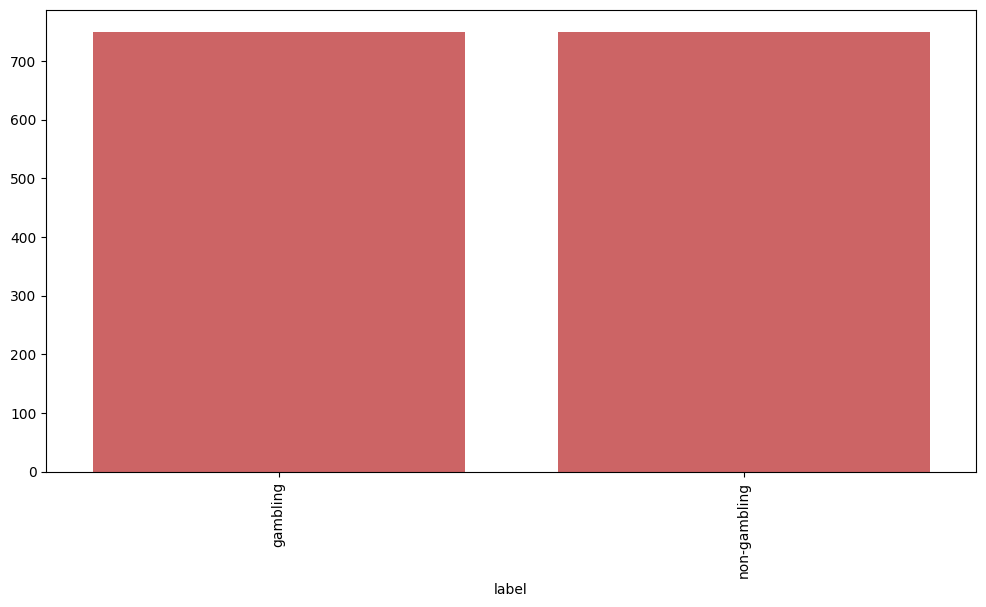

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
pd.set_option("display.max_colwidth", 200)
import warnings
warnings.filterwarnings('ignore')

cnt_label = df['label'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=cnt_label.index, y=cnt_label.values, alpha=0.8, color=color[3])
plt.xticks(rotation='vertical')
plt.show()

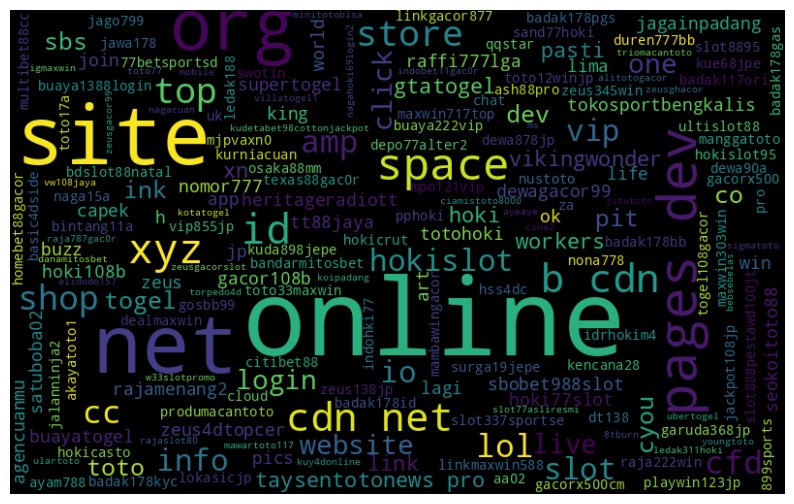

In [5]:
from wordcloud import WordCloud

all_words_gambling = ' '.join([text for text in df[df['label'] == 'gambling']['domain']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
             max_font_size=110).generate(all_words_gambling)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

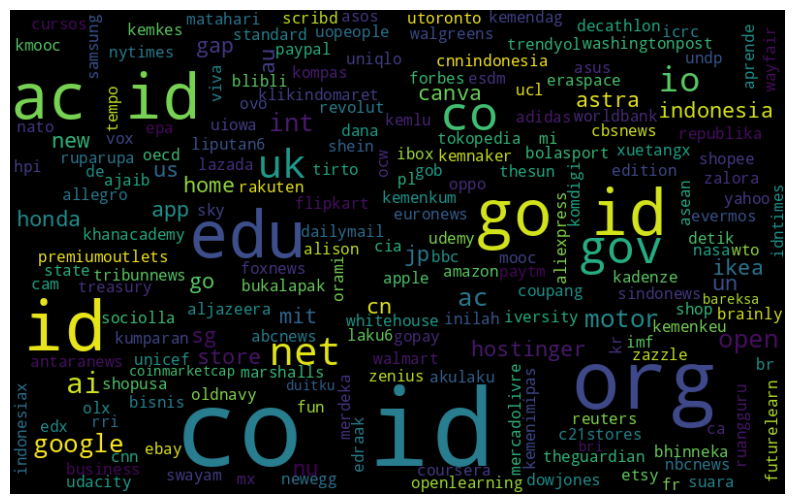

In [6]:
all_words_non_gambling = ' '.join([text for text in df[df['label'] == 'non-gambling']['domain']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
             max_font_size=110).generate(all_words_non_gambling)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

# Feature Extraction

In [ ]:
import tldextract

def clean_url(url):
    extracted = tldextract.extract(url)
    subdomain = extracted.subdomain  # ambil subdomain
    domain = extracted.domain  # ambil domain
    tld = extracted.suffix  # ambil TLD
    # Gabungkan subdomain (jika ada), domain, dan TLD
    return (subdomain + " " if subdomain else "") + domain + " " + tld

# Asumsikan df adalah DataFrame yang berisi kolom 'original_url'
df['text'] = df['original_url'].apply(clean_url)

df.head()


,id,domain,original_url,label,text
0,1,garuda368jp.art,https://garuda368jp.art,gambling,garuda368jp art
1,2,gacor108b.xyz,https://gacor108b.xyz,gambling,gacor108b xyz
2,3,kuda898jepe.online,https://kuda898jepe.online,gambling,kuda898jepe online
3,4,zeus345win.online,https://zeus345win.online,gambling,zeus345win online
4,5,zeus138jp.org,https://zeus138jp.org,gambling,zeus138jp org


### Bag-of-Words Features

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

vec_bow = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2
)

Url_bow = vec_bow.fit_transform(df['text'])
print(f"Jumlah fitur (vocabulary size) untuk BOW: {len(vec_bow.get_feature_names_out())}")

Jumlah fitur (vocabulary size) untuk BOW: 144


### N-GRAM Features

In [9]:
from sklearn.pipeline import FeatureUnion

vec_char = CountVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3
)

vec_word = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=2
)

vec_char_word = FeatureUnion([
    ("char", vec_char),
    ("word", vec_word)
])

Url_char_word = vec_char_word.fit_transform(df['text'])
print(f"Jumlah fitur gabungan (char+word) untuk N-gram: {len(vec_char_word.get_feature_names_out())}")


Jumlah fitur gabungan (char+word) untuk N-gram: 2838


### TF-IDF features

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec_char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3
)

vec_word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 1),
    min_df=2
)

vec_tfidf = FeatureUnion([
    ("char", vec_char_tfidf),
    ("word", vec_word_tfidf)
])

Url_tfidf = vec_tfidf.fit_transform(df['text'])
print(f"Jumlah fitur gabungan (char+word TF-IDF): {len(vec_tfidf.get_feature_names_out())}")

Jumlah fitur gabungan (char+word TF-IDF): 2838


### Split Dataset

In [11]:
from sklearn.model_selection import train_test_split

y = df['label']

# Split data sekali untuk semua model
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    Url_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_train_char, X_test_char, _, _ = train_test_split(
    Url_char_word, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    Url_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Model Training

In [12]:
from sklearn.metrics import accuracy_score, classification_report

def train_eval(X_train, X_test, y_train, y_test, model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))
    
    return acc

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "MultinomialNB": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

In [14]:
results = {}

for model_name, model in models.items():
    print(f"\nEvaluating with {model_name}...")
    
    # BOW
    results[f"BOW - {model_name}"] = train_eval(
        X_train_bow, X_test_bow, y_train, y_test,
        model, f"Bag-of-Words + {model_name}"
    )
    
    # Char + Word
    results[f"CHAR+WORD - {model_name}"] = train_eval(
        X_train_char, X_test_char, y_train, y_test,
        model, f"Character + Word N-Gram + {model_name}"
    )
    
    # TF-IDF
    results[f"TF-IDF - {model_name}"] = train_eval(
        X_train_tfidf, X_test_tfidf, y_train, y_test,
        model, f"TF-IDF + {model_name}"
    )


Evaluating with MultinomialNB...

MODEL: Bag-of-Words + MultinomialNB
Accuracy: 0.7733333333333333


              precision    recall  f1-score   support

    gambling       0.89      0.63      0.73       150
non-gambling       0.71      0.92      0.80       150

    accuracy                           0.77       300
   macro avg       0.80      0.77      0.77       300
weighted avg       0.80      0.77      0.77       300


MODEL: Character + Word N-Gram + MultinomialNB
Accuracy: 0.89
              precision    recall  f1-score   support

    gambling       0.95      0.82      0.88       150
non-gambling       0.84      0.96      0.90       150

    accuracy                           0.89       300
   macro avg       0.90      0.89      0.89       300
weighted avg       0.90      0.89      0.89       300


MODEL: TF-IDF + MultinomialNB
Accuracy: 0.9033333333333333
              precision    recall  f1-score   support

    gambling       0.96      0.84      0.90       150
non-gambling       0.86      0.97      0.91       150

    accuracy                           0.90       300
   ma

# Evaluation

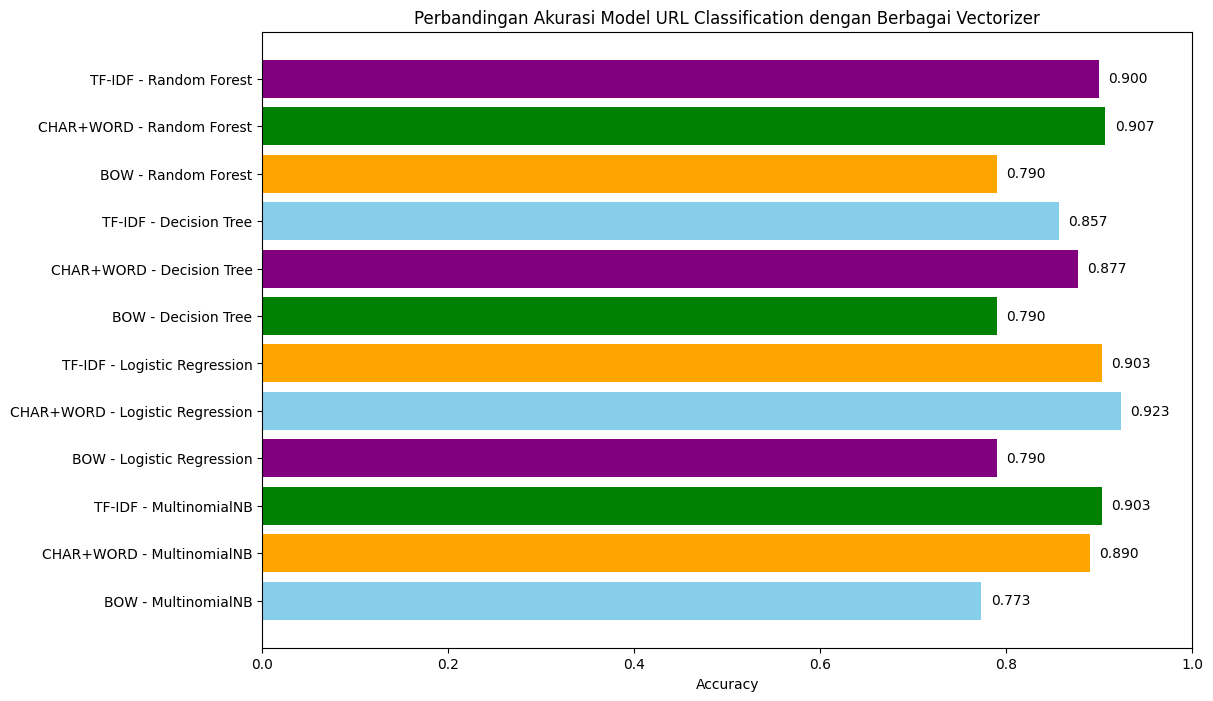

In [15]:
# Create a list of models and scores
model_comparison = list(results.keys())
scores = list(results.values())

# Plot the results
plt.figure(figsize=(12,8))
bars = plt.barh(model_comparison, scores, color=['skyblue', 'orange', 'green', 'purple'])

plt.title("Perbandingan Akurasi Model URL Classification dengan Berbagai Vectorizer")
plt.xlabel("Accuracy")
plt.xlim(0, 1)

# Add labels to the bars
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", 
             va='center', color='black', fontsize=10)

plt.show()

# Hyperparameter Tuning

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10],  # Regularization strength
    'max_iter': [1000],  # Jumlah iterasi
    'solver': ['liblinear', 'saga'],  # Pilihan solver
    'penalty': ['l2'],  # L2 lebih sering digunakan
    'class_weight': [None],  # Tidak perlu balanced jika kelas relatif seimbang
    'tol': [1e-4],  # Ambang batas untuk konvergensi
    'fit_intercept': [True]  # Biasanya kita ingin intercept
}
# Logistic Regression
logreg = LogisticRegression()

# GridSearchCV untuk mencari parameter terbaik
grid_search = GridSearchCV(logreg, param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV pada data training
grid_search.fit(X_train_char, y_train)

# Menampilkan parameter terbaik yang ditemukan
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# Model terbaik
best_logreg = grid_search.best_estimator_

# perbaindahan sebelum hyperparameter tuning
print("Akurasi sebelum tuning:", results["CHAR+WORD - Logistic Regression"])
print("Akurasi setelah tuning:", accuracy_score(y_test, best_logreg.predict(X_test_char)))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'C': 10, 'class_weight': None, 'fit_intercept': True, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga', 'tol': 0.0001}
Best Cross-validation Score: 0.93
Akurasi sebelum tuning: 0.9233333333333333
Akurasi setelah tuning: 0.9233333333333333


In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi menggunakan model terbaik pada test set
y_pred = best_logreg.predict(X_test_char)

# Evaluasi model
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Set Accuracy: 0.9233333333333333
              precision    recall  f1-score   support

    gambling       0.95      0.89      0.92       150
non-gambling       0.90      0.95      0.93       150

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



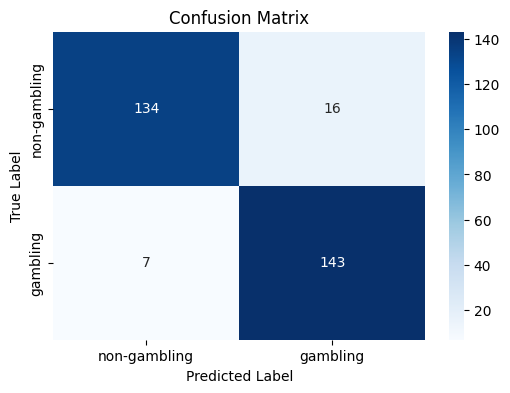

In [18]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)

label_names = ["non-gambling", "gambling"]
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
import joblib
import os

# buat bin directory jika belum ada
os.makedirs('bin', exist_ok=True)

# Menyimpan model terbaik
joblib.dump(best_logreg, 'bin/domain_text_classifier_model.pkl')
# Menyimpan vectorizer yang sudah dilatih
joblib.dump(vec_char_word, 'bin/domain_text_vectorizer.pkl')

['bin/domain_text_vectorizer.pkl']

In [20]:
import joblib

# Memuat model dan vectorizer yang sudah disimpan
best_logreg = joblib.load('bin/domain_text_classifier_model.pkl')  # Model Logistic Regression
vec_char_word = joblib.load('bin/domain_text_vectorizer.pkl')  # FeatureUnion (CHAR+WORD)

# Cek apakah vectorizer sudah dipelajari
print(f"Vectorizer vocabulary size: {len(vec_char_word.get_feature_names_out())}")

Vectorizer vocabulary size: 2838


In [ ]:
def predict_url(input_url, model, vectorizer):
    text_input = clean_url(input_url)

    text_vectorized = vectorizer.transform([text_input])

    predicted_label = model.predict(text_vectorized)[0]

    prediction_probabilities = model.predict_proba(text_vectorized)[0]
    
    # Cek indeks kelas untuk predicted_label
    # Misalnya, gambling = 1 dan non-gambling = 0
    class_index = model.classes_.tolist().index(predicted_label)
    
    # Ambil probabilitas untuk kelas yang diprediksi dan kalikan dengan 100 untuk confidence
    confidence = prediction_probabilities[class_index] * 100

    return predicted_label, confidence

In [22]:
urls = [
    ("https://presidenri.go.id", "non-gambling"),
    ("https://bgn.go.id", "non-gambling"),
    ("https://kampusmerdeka.kemdikbud.go.id", "non-gambling"),
    ("https://maxslot88kita.xyz", "gambling"),
    ("https://berikan-aku-10-link.netlify.app", "gambling"),
    ("https://gustoristobar.com", "gambling"),
    ("https://hargayin.com", "gambling"),
]

# Prediksi dan tampilkan hasil untuk setiap URL
for url, actual_label in urls:
    predicted_label, confidence = predict_url(url, best_logreg, vec_char_word)
    
    is_correct = "Benar" if predicted_label == actual_label else "Salah"
    
    print("="*50)
    print(f"URL: {url}")
    print(f"Prediksi: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Label Sebenarnya: {actual_label}")
    print(f"Status: {is_correct}")
    print("="*50 + "\n")

URL: https://presidenri.go.id
Prediksi: non-gambling
Confidence: 100.00%
Label Sebenarnya: non-gambling
Status: Benar

URL: https://bgn.go.id
Prediksi: non-gambling
Confidence: 99.96%
Label Sebenarnya: non-gambling
Status: Benar

URL: https://kampusmerdeka.kemdikbud.go.id
Prediksi: non-gambling
Confidence: 99.71%
Label Sebenarnya: non-gambling
Status: Benar

URL: https://maxslot88kita.xyz
Prediksi: gambling
Confidence: 100.00%
Label Sebenarnya: gambling
Status: Benar

URL: https://berikan-aku-10-link.netlify.app
Prediksi: gambling
Confidence: 93.48%
Label Sebenarnya: gambling
Status: Benar

URL: https://gustoristobar.com
Prediksi: non-gambling
Confidence: 52.92%
Label Sebenarnya: gambling
Status: Salah

URL: https://hargayin.com
Prediksi: non-gambling
Confidence: 84.08%
Label Sebenarnya: gambling
Status: Salah

